In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from snowflake.snowpark import Session

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
connection_parameters = {
    "account": "IJYGGJU-WI05238",
    "user": "Shank227",
    "password": "ShashankB2207$",
    "warehouse": "COMPUTE_WH",
    "database": "BANK_SEGMENTATION_DB",
    "schema": "PUBLIC",
    "role": "ACCOUNTADMIN"
}

In [3]:
session = Session.builder.configs(connection_parameters).create()
session.sql("SELECT CURRENT_VERSION()").show()

-----------------------
|"CURRENT_VERSION()"  |
-----------------------
|10.23.103            |
-----------------------



In [13]:
df = session.table("BANK_MARKETING_PROCESSED").to_pandas()

In [14]:
df.isnull().sum().sum()

np.int64(0)

In [19]:
for col in df.columns:
    print(col)

AGE
DURATION
CAMPAIGN
PDAYS
PREVIOUS
EMPLOYMENT_RATE
CONSUMER_PRICE_INDEX
CONSUMER_CONFIDENCE_INDEX
EURIBOR3M
EMPLOYEES_COUNT
JOB_BLUE_COLLAR
JOB_ENTREPRENEUR
JOB_HOUSEMAID
JOB_MANAGEMENT
JOB_RETIRED
JOB_SELFEMPLOYED
JOB_SERVICES
JOB_STUDENT
JOB_TECHNICIAN
JOB_UNEMPLOYED
JOB_UNKNOWN
MARITAL_MARRIED
MARITAL_SINGLE
MARITAL_UNKNOWN
EDUCATION_BASIC6Y
EDUCATION_BASIC9Y
EDUCATION_HIGHSCHOOL
EDUCATION_ILLITERATE
EDUCATION_PROFESSIONALCOURSE
EDUCATION_UNIVERSITYDEGREE
EDUCATION_UNKNOWN
DEFAULT_UNKNOWN
DEFAULT_YES
HOUSING_UNKNOWN
HOUSING_YES
LOAN_UNKNOWN
LOAN_YES
CONTACT_TELEPHONE
MONTH_AUG
MONTH_DEC
MONTH_JUL
MONTH_JUN
MONTH_MAR
MONTH_MAY
MONTH_NOV
MONTH_OCT
MONTH_SEP
DAY_OF_WEEK_MON
DAY_OF_WEEK_THU
DAY_OF_WEEK_TUE
DAY_OF_WEEK_WED
POUTCOME_NONEXISTENT
POUTCOME_SUCCESS
AGE_GROUP
CONTACTED_BEFORE
HIGH_CAMPAIGN


In [24]:
df.info()
df.isnull().sum().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 56 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   AGE                           41188 non-null  float64
 1   DURATION                      41188 non-null  float64
 2   CAMPAIGN                      41188 non-null  float64
 3   PDAYS                         41188 non-null  float64
 4   PREVIOUS                      41188 non-null  float64
 5   EMPLOYMENT_RATE               41188 non-null  float64
 6   CONSUMER_PRICE_INDEX          41188 non-null  float64
 7   CONSUMER_CONFIDENCE_INDEX     41188 non-null  float64
 8   EURIBOR3M                     41188 non-null  float64
 9   EMPLOYEES_COUNT               41188 non-null  float64
 10  JOB_BLUE_COLLAR               41188 non-null  float64
 11  JOB_ENTREPRENEUR              41188 non-null  float64
 12  JOB_HOUSEMAID                 41188 non-null  float64
 13  J

np.int64(0)

In [25]:
np.isinf(df).sum().sum()

np.int64(0)

In [26]:
#Starting ELBOW method for choosing correct amount clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(df)

    wcss.append(kmeans.inertia_)

In [27]:
wcss

[2115419.9782568915,
 2017100.4121539432,
 1948256.399225663,
 1873459.608815565,
 1828119.295868731,
 1783623.5049221516,
 1723420.8269777086,
 1690183.475398575,
 1636328.2541165103]

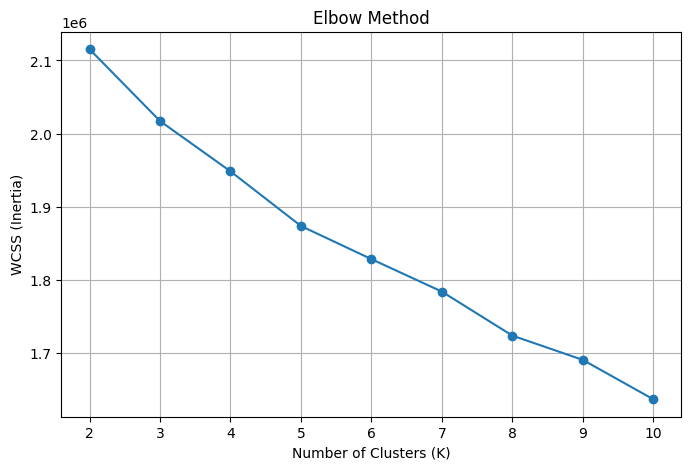

In [28]:
# Plot the Elbow Method graph

plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")

plt.grid(True)

plt.show()

In [29]:
# Import the silhouette score metric
from sklearn.metrics import silhouette_score

# Store silhouette scores for different values of K
silhouette_scores = []

# Test K values from 2 to 10
for k in range(2, 11):

    # Initialize the K-Means model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Fit the model and get cluster labels
    cluster_labels = kmeans.fit_predict(df)

    # Calculate the silhouette score
    score = silhouette_score(df, cluster_labels)

    # Store the score
    silhouette_scores.append(score)

In [30]:
silhouette_scores

[0.12370178331450181,
 0.0879329173991957,
 0.05976960371131889,
 0.0663979138516044,
 0.07901058555415781,
 0.08590813246879096,
 0.091137203238603,
 0.09343526663440853,
 0.10334269130777562]

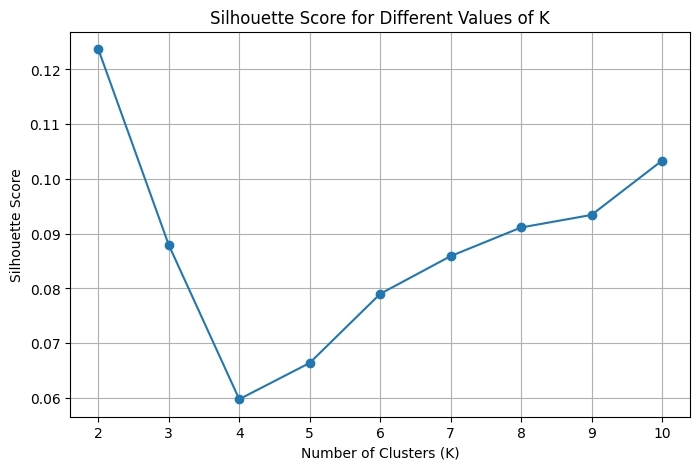

In [31]:
# Plot the Silhouette Scores

plt.figure(figsize=(8,5))

plt.plot(range(2,11), silhouette_scores, marker='o')

plt.title("Silhouette Score for Different Values of K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.grid(True)

plt.show()